In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import *

import warnings
warnings.filterwarnings("ignore")

In [72]:
df = pd.read_csv("D:\\Data Sets\\heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [74]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [75]:
df.shape

(920, 16)

The dataset has many columns with null values. But "ca" and "thal" has more than 50% values null, so we will drop those two columns.

In [76]:
df.drop(columns=["ca", "thal"], inplace=True)



In [77]:
df["num"].replace({ 2: 1, 3: 1, 4: 1}, inplace=True)

df["num"].value_counts()

num
1    509
0    411
Name: count, dtype: int64

In [78]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns
print(f"numerical cols: {numerical_cols}")
print(f"categorical cols: {categorical_cols}")

numerical cols: Index(['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')
categorical cols: Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope'], dtype='object')


### EDA

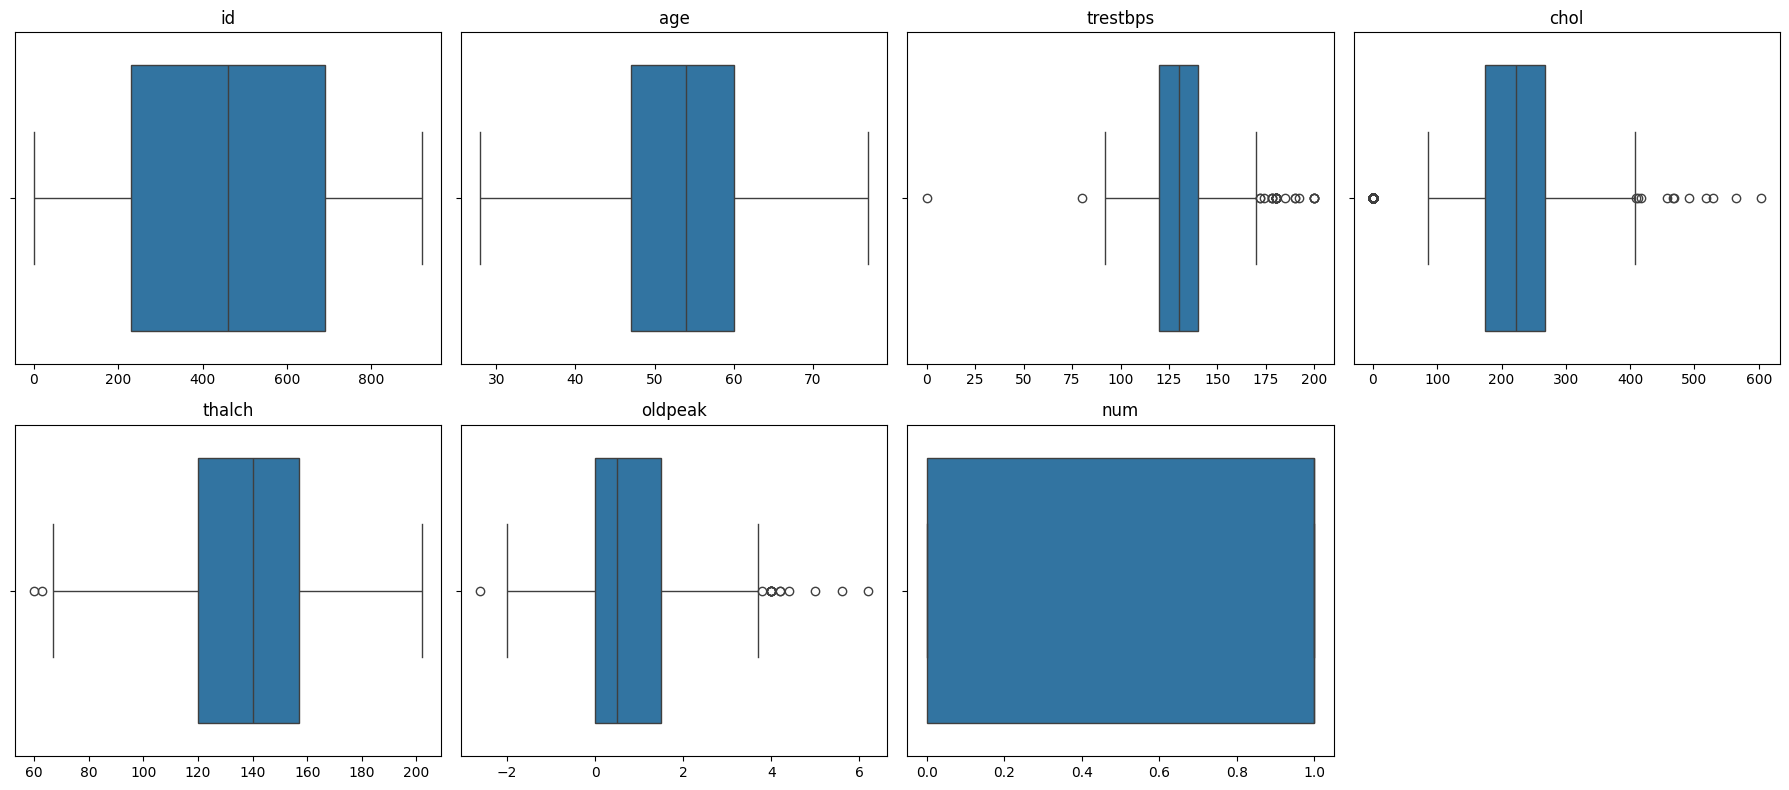

In [79]:
num_features = len(numerical_cols)
cols = 4
rows = math.ceil(num_features / cols)

plt.figure(figsize=(18, 4 * rows))

for idx, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, idx)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.xlabel("")

for idx in range(num_features + 1, rows * cols + 1):
    plt.subplot(rows, cols, idx)
    plt.axis("off")

plt.tight_layout()
plt.show()

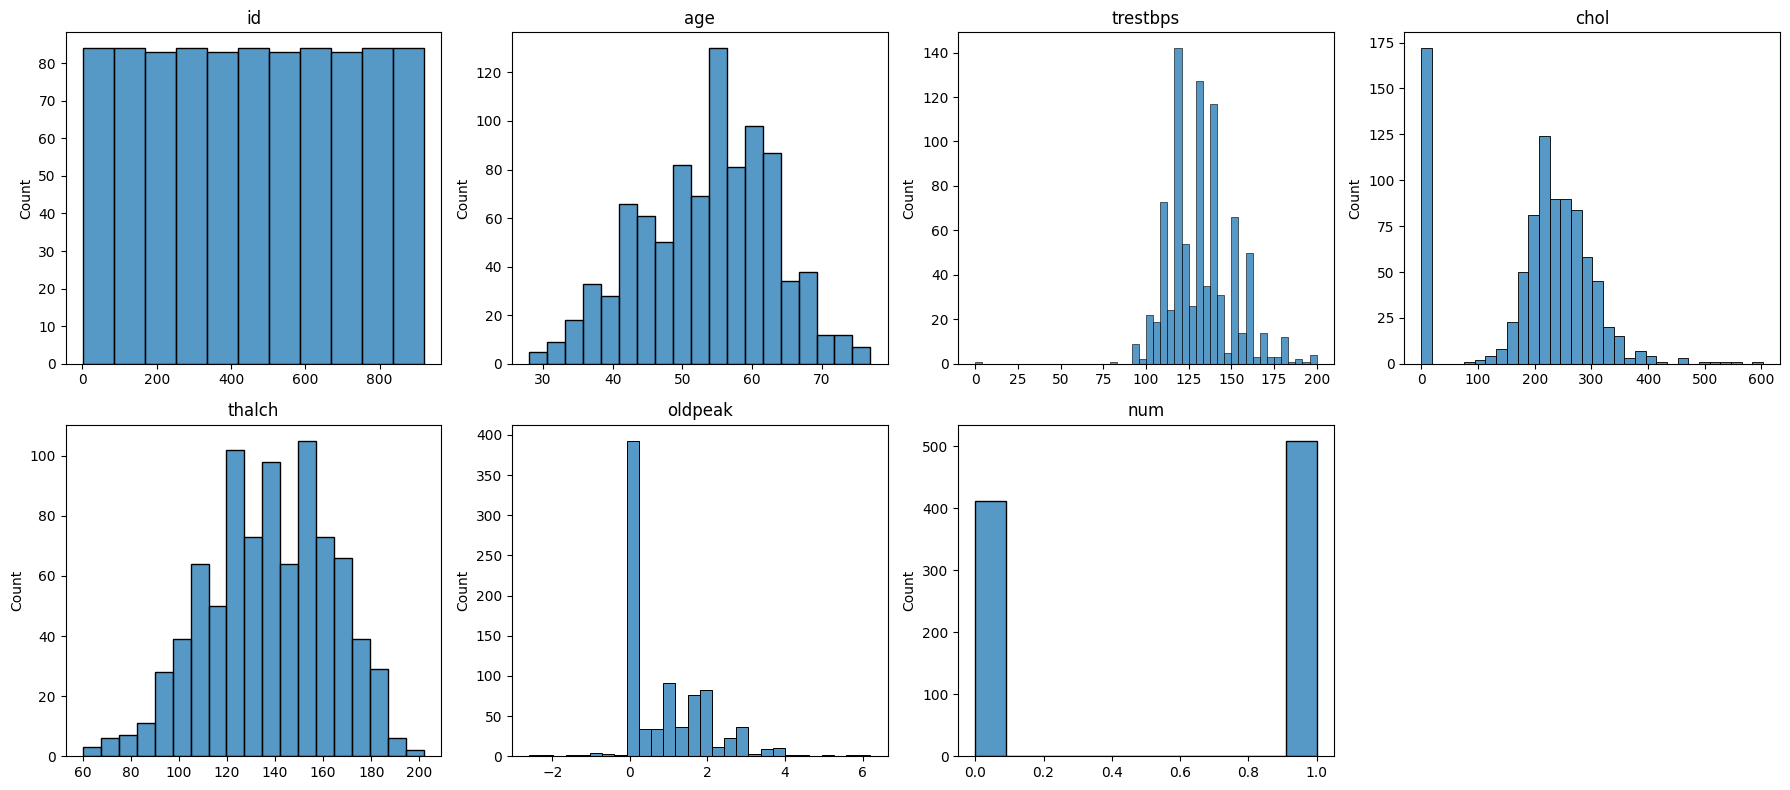

In [80]:
num_features = len(numerical_cols)
cols = 4
rows = math.ceil(num_features / cols)

plt.figure(figsize=(18, 4 * rows))

for idx, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, idx)
    sns.histplot(x=df[col])
    plt.title(col)
    plt.xlabel("")

for idx in range(num_features + 1, rows * cols + 1):
    plt.subplot(rows, cols, idx)
    plt.axis("off")

plt.tight_layout()
plt.show()

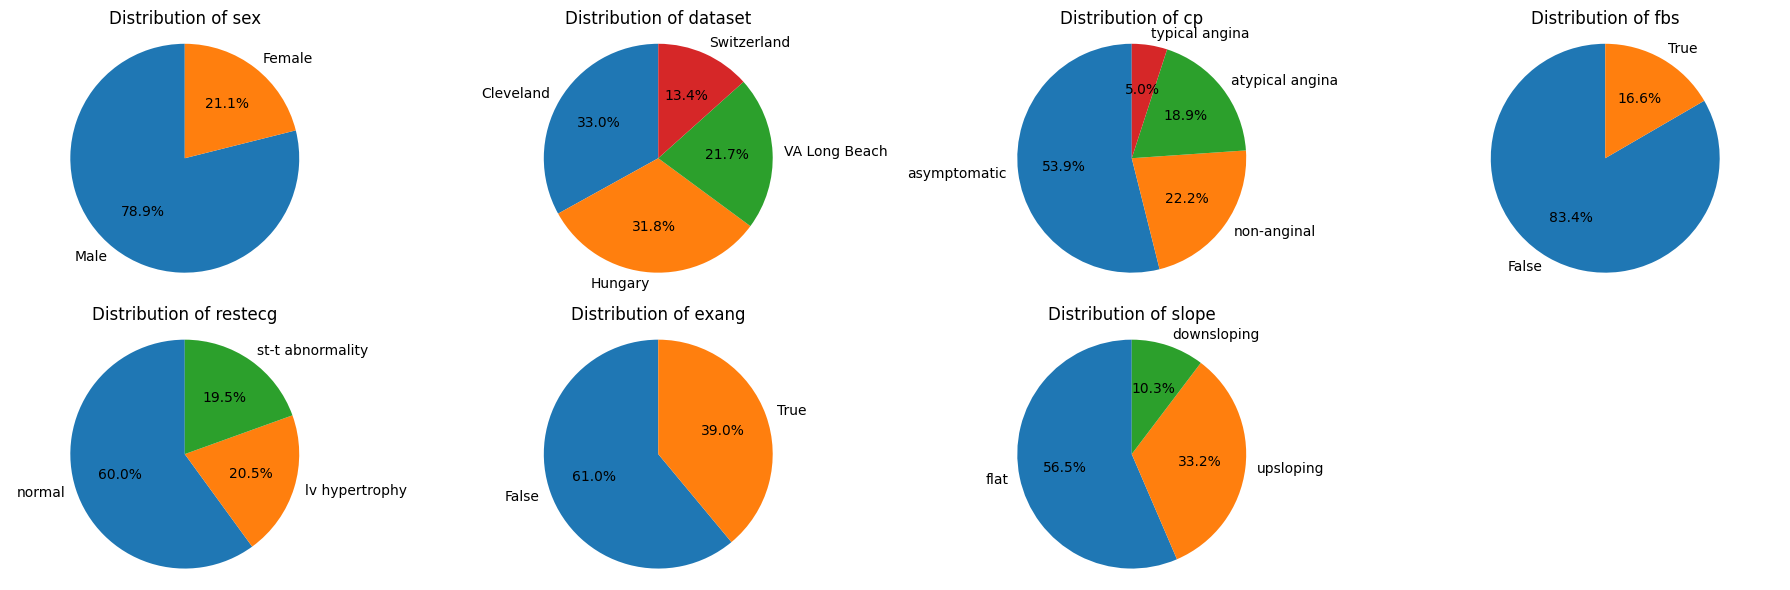

In [81]:
num_features = len(categorical_cols)
cols = 4
rows = math.ceil(num_features / cols)

plt.figure(figsize=(18, 3 * rows))

for idx, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, cols, idx)

    counts = df[col].value_counts()
    plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90)

    plt.title(f"Distribution of {col}")
    plt.axis("equal")

for idx in range(num_features + 1, rows * cols + 1):
    plt.subplot(rows, cols, idx)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Conclusion:
- Some of our columns have outliers that we will have to handle
- Our data is not normally distributed but we can fix that using standard scaling after data splitting
- Our data has mostly male patients with 78.9%
- Our data has the most entry from cleaveland with 33%
- More than half of the people has asymptotic chest pain
- 85% of the people doesnt have Fasting blood sugar
- 60% people have normal Resting Electrocardiographic Results
- 63.4% people dont have Exercise-Induced Angina.
- 71% people have flat slope of ST.
- 74% people have normal results on thallium stress test.
- Our target variable is fairly balanced.

In [82]:
for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
    
df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64

We impude the null values with mean in the numerical columns and with mode in the categorical columns.

In [83]:
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

### Feature Selection

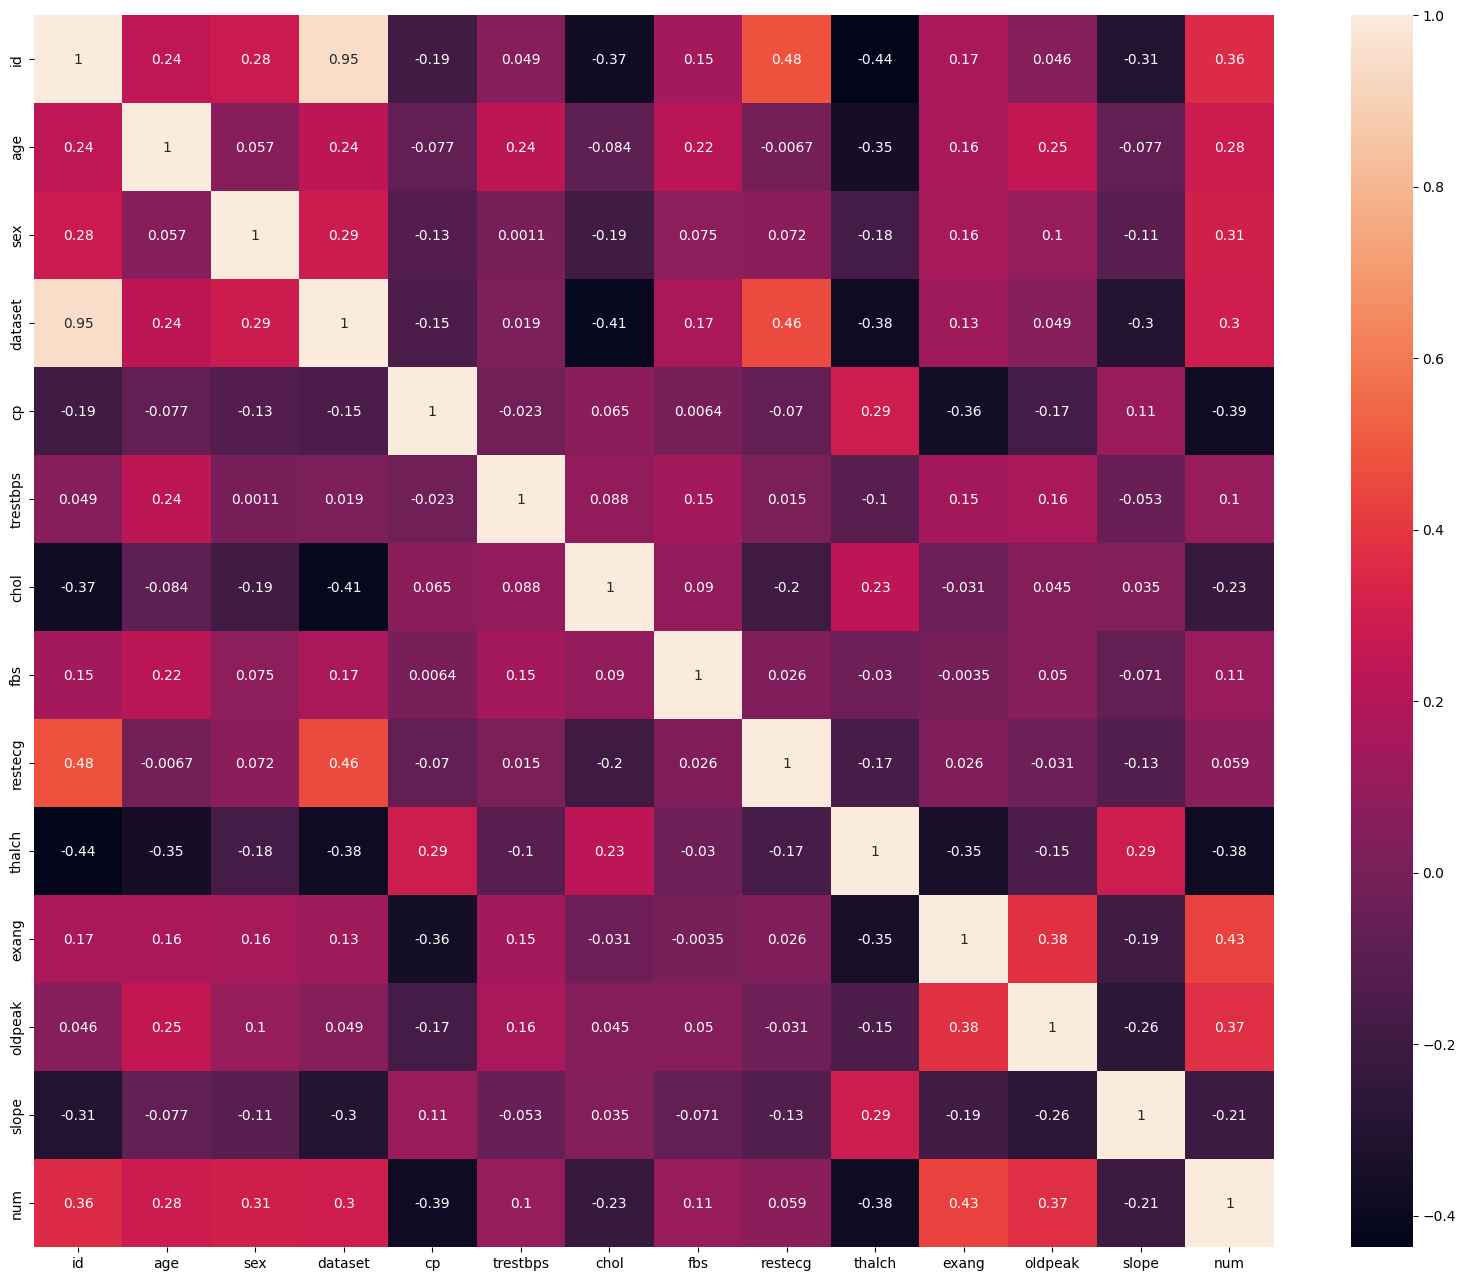

In [84]:
plt.figure(figsize=(20,16))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [85]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

We clip the outliers to the boundary values instead of removing them to retain data size.

### Splitting the data

In [86]:
X = df.drop(columns=["num"])
y = df["num"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [87]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Model Training

In [88]:
dtc = DecisionTreeClassifier()

dtc.fit(X_train, y_train)

DecisionTreeClassifier()

In [89]:
y_pred_train_data = dtc.predict(X_train)
print(f"y_pred_train_data Shape: {y_pred_train_data.shape}")

y_pred_test_data = dtc.predict(X_test)
print(f"y_pred_test_data Shape: {y_pred_test_data.shape}")

y_pred_train_data Shape: (736,)
y_pred_test_data Shape: (184,)


In [90]:
print(classification_report(y_train, y_pred_train_data))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       336
           1       1.00      1.00      1.00       400

    accuracy                           1.00       736
   macro avg       1.00      1.00      1.00       736
weighted avg       1.00      1.00      1.00       736



In [91]:
print(classification_report(y_test, y_pred_test_data))

              precision    recall  f1-score   support

           0       0.71      0.84      0.77        75
           1       0.87      0.76      0.81       109

    accuracy                           0.79       184
   macro avg       0.79      0.80      0.79       184
weighted avg       0.81      0.79      0.80       184



The Decision Tree classifier achieved perfect performance on the training set (accuracy = 1.00), but significantly lower performance on the test set (accuracy = 0.79). This large gap indicates that the model has overfitted the training data and does not generalize well to unseen samples. Overfitting occurs because the tree was allowed to grow too deep, capturing noise and specific patterns in the training data.

### Hyperparameter Tuning

In [92]:
param_grid = {
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
    "max_features": [None, "sqrt", "log2"],
}

In [93]:
dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 20, 30],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [94]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 20}

Best Cross-Validation Accuracy:
0.8559845559845559


In [95]:
best_dt = grid_search.best_estimator_

y_pred_test = best_dt.predict(X_test)

In [96]:
print("Classification Report (Test Data):")
print(classification_report(y_test, y_pred_test))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.72      0.80      0.76        75
           1       0.85      0.79      0.82       109

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.80      0.79      0.79       184

Confusion Matrix:
[[60 15]
 [23 86]]


After hyperparameter tuning, the accuracy of decision tree classifier didn't really change.